In [ ]:
!pip install tensorflow==2.12.0

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
def fetch_data(ticker, start_date="2013-01-01", end_date="2023-12-31"):
    data = yf.download(ticker, start=start_date, end=end_date)
    data['Date'] = data.index
    data.reset_index(drop=True, inplace=True)
    return data


In [ ]:
# we are training on ten popular stocks
stock_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NVDA', 'META', 'AMD', 'JNJ', 'XOM']



In [ ]:
stock_tickers

['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NVDA', 'META', 'AMD', 'JNJ', 'XOM']

In [ ]:
for i in range(0 , len(stock_tickers)):
    globals()[stock_tickers[i]] = fetch_data(stock_tickers[i])


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
company_list =  [AAPL, MSFT, GOOGL, AMZN, TSLA, NVDA, META, AMD, JNJ, XOM ]


In [ ]:
MSFT.head(20)

Price,Adj Close,Close,High,Low,Open,Volume,Date
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT,
0,22.406961,27.620001,27.730000,27.150000,27.250000,52899300,2013-01-02
1,22.106796,27.250000,27.650000,27.160000,27.629999,48294400,2013-01-03
2,21.693056,26.740000,27.340000,26.730000,27.270000,52521100,2013-01-04
3,21.652493,26.690001,26.879999,26.639999,26.770000,37110400,2013-01-07
4,21.538916,26.549999,26.790001,26.459999,26.750000,44703100,2013-01-08
5,21.660606,26.700001,26.750000,26.559999,26.719999,49047900,2013-01-09
6,21.465895,26.459999,26.980000,26.290001,26.650000,71431300,2013-01-10
7,21.766066,26.830000,26.930000,26.280001,26.490000,55512100,2013-01-11
8,21.814734,26.889999,27.080000,26.760000,26.900000,48324400,2013-01-14


In [ ]:
MSFT.describe()


Price,Adj Close,Close,High,Low,Open,Volume,Date
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT,
count,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2.768000e+03,2768
mean,133.032109,139.171243,140.500921,137.699050,139.118212,3.183635e+07,2018-07-01 05:52:11.791907584
min,21.465895,26.459999,26.750000,26.280001,26.490000,7.425600e+06,2013-01-02 00:00:00
25%,41.721780,48.579999,48.917499,48.072501,48.575002,2.221302e+07,2015-09-30 18:00:00
50%,94.598309,101.085003,101.805000,99.574997,101.094997,2.787770e+07,2018-06-30 12:00:00
75%,228.756271,235.532505,238.005001,232.392498,235.269997,3.639475e+07,2021-03-31 06:00:00
max,379.859497,382.700012,384.299988,378.160004,383.760010,2.484285e+08,2023-12-29 00:00:00
std,102.708962,102.621768,103.656363,101.486758,102.591663,1.640070e+07,NaN


# plotting graphs to observe relation

## viewing closing price of stock

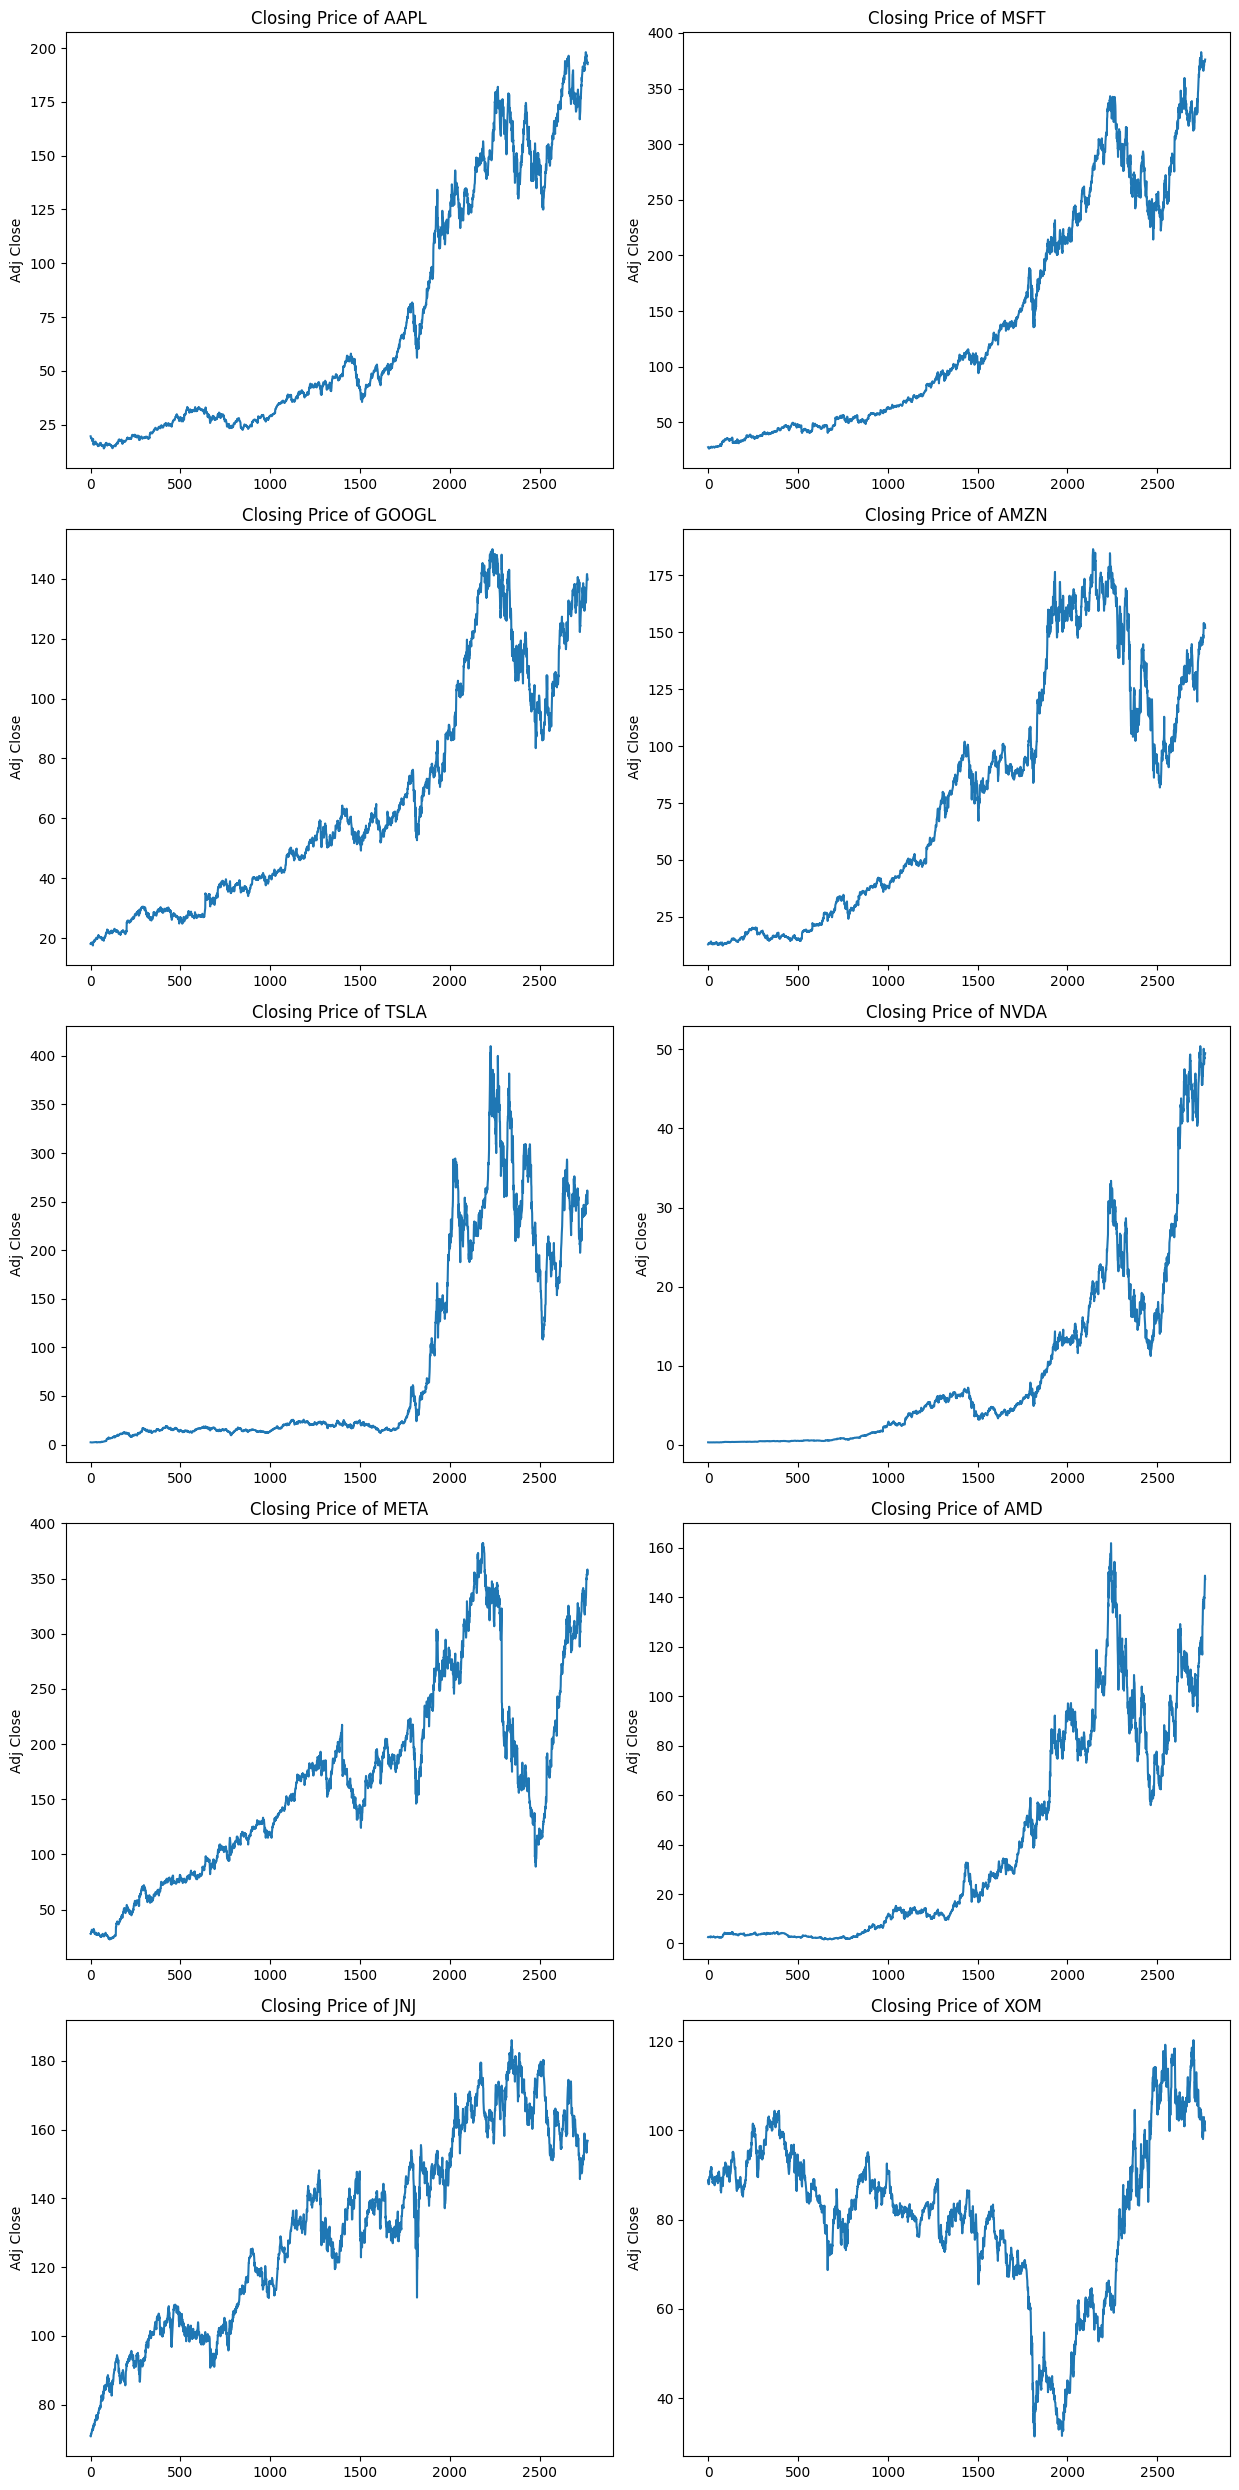

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5,2, figsize=(12.5, 25))
axes = axes.flatten()
for i, (company, ticker) in enumerate(zip(company_list, stock_tickers)):
    axes[i].plot(company["Close"])
    axes[i].set_ylabel("Adj Close")
    axes[i].set_title(f"Closing Price of {ticker}")

# to prevent overlapping
plt.tight_layout()
plt.show()

## plot for sale volume

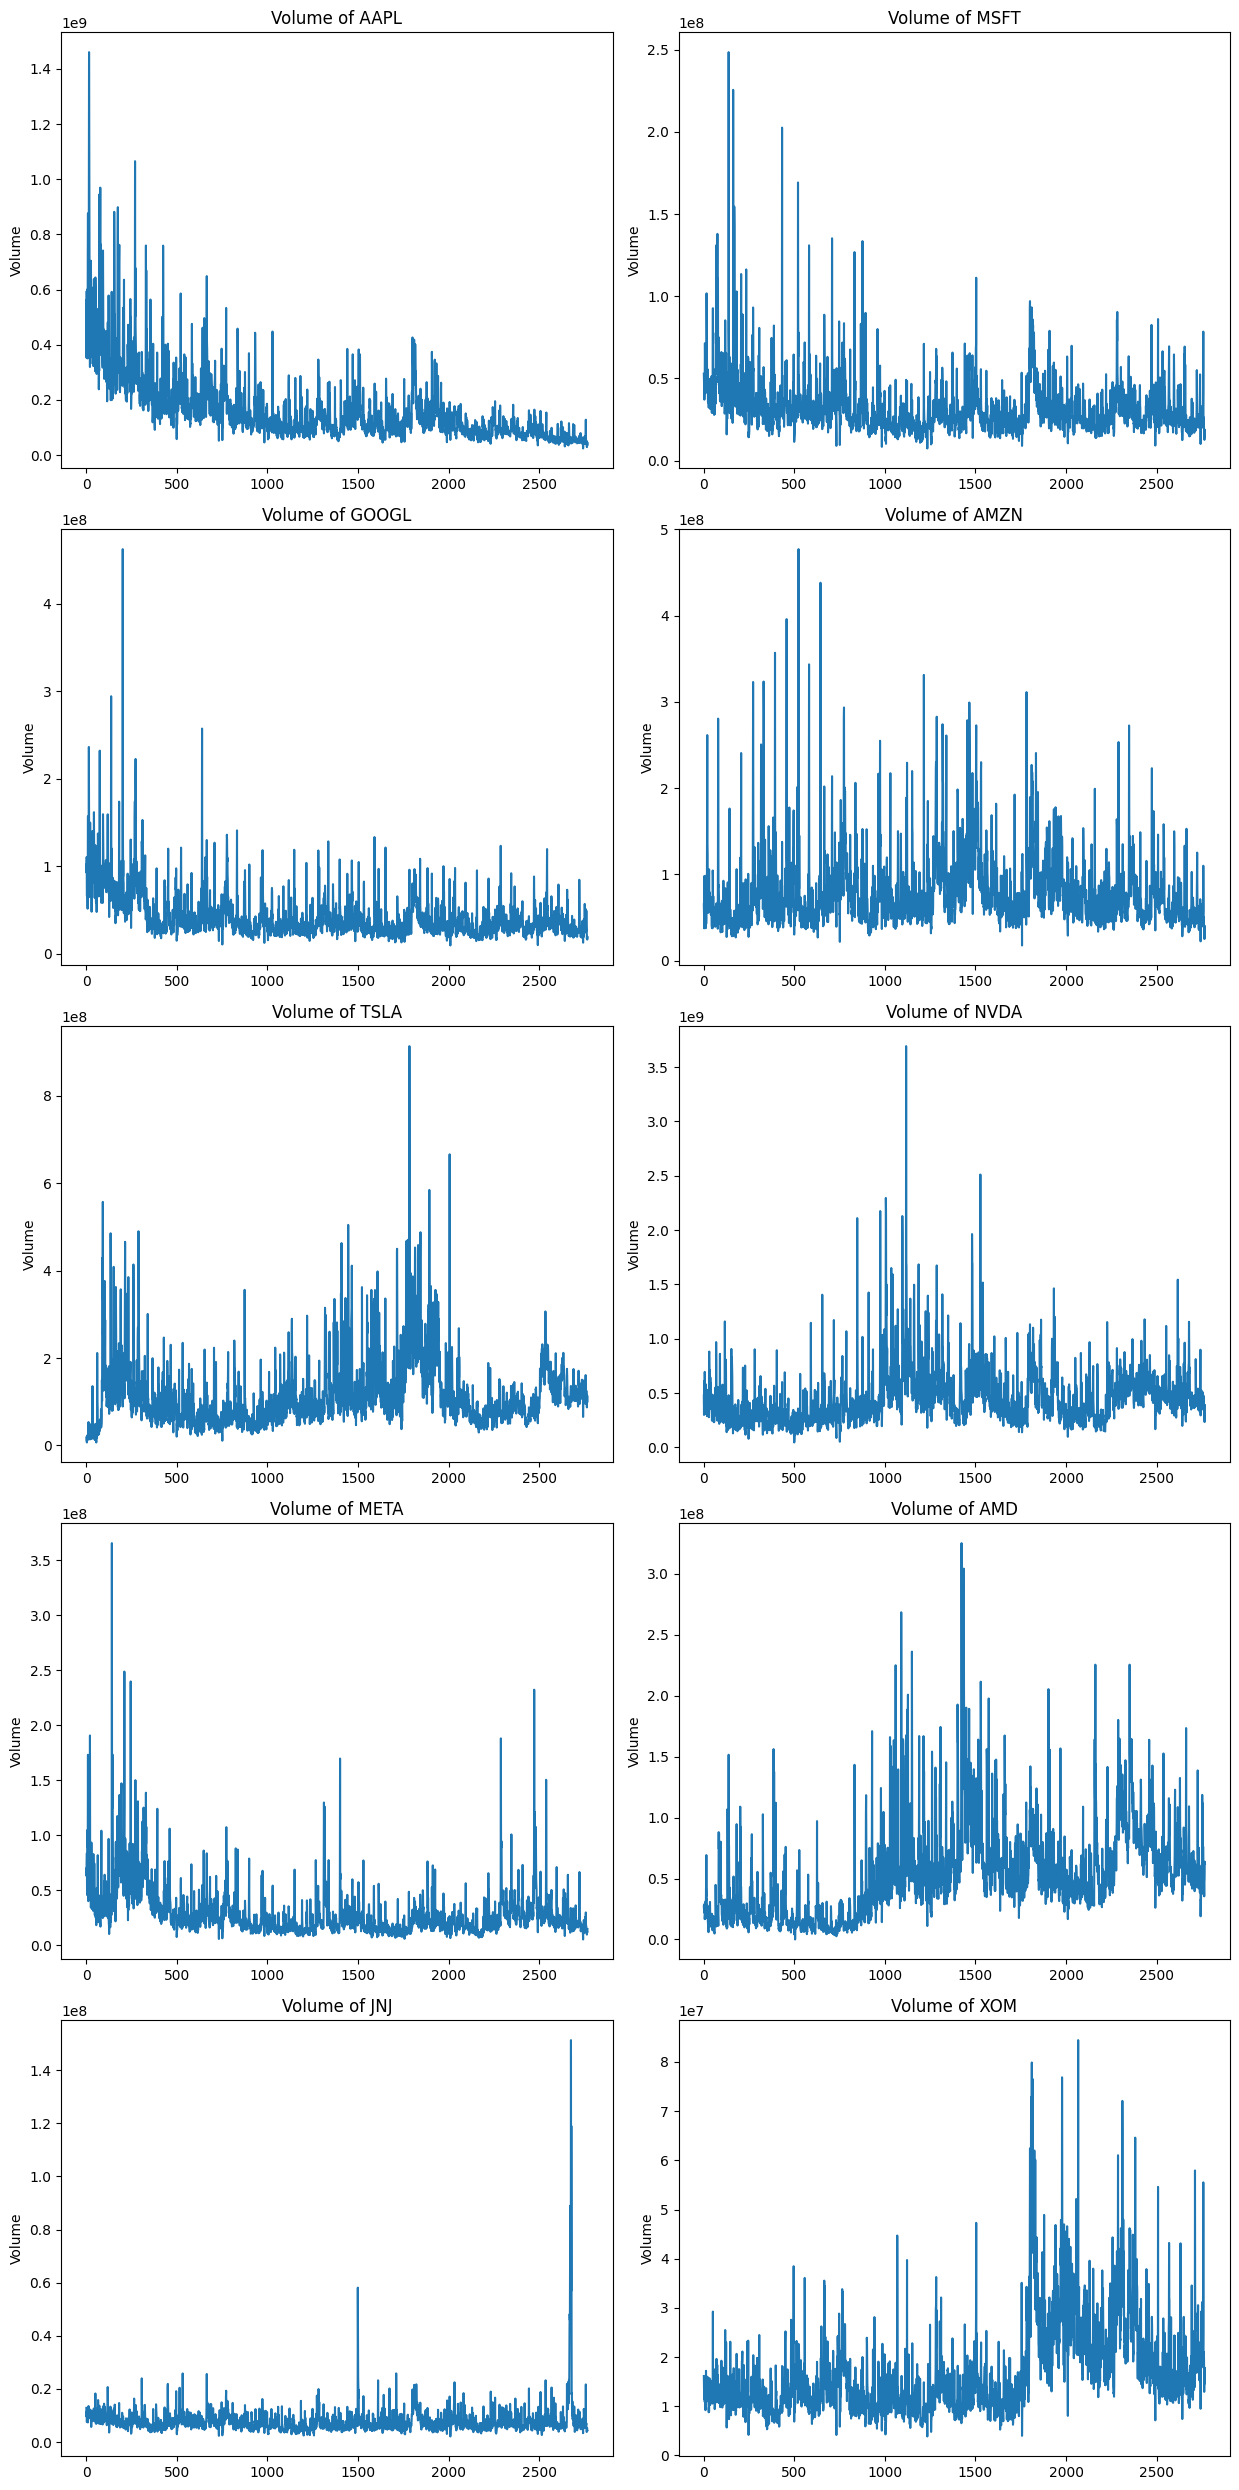

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5,2 , figsize=(12.5, 25))
axes = axes.flatten()
for i, (company, ticker) in enumerate(zip(company_list, stock_tickers)):
    axes[i].plot(company["Volume"])
    axes[i].set_ylabel("Volume")
    axes[i].set_title(f"Volume of {ticker}")

# to prevent overlapping
plt.tight_layout()
plt.show()

# NOW CREATING A DATAFRAME FOR 10 YEARS
2014 TO 2024
* 8 years for training
* 1 for validation
* 1 for testing


In [ ]:
stock_tickers

['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NVDA', 'META', 'AMD', 'JNJ', 'XOM']

In [ ]:
# Download 2 days of data for each ticker, grouping by 'Ticker' to structure the DataFrame with multi-level columns
df = yf.download(stock_tickers, group_by='Ticker',
                 start = "2000-01-01" ,
                 end = "2024-01-01")

# Transform the DataFrame: stack the ticker symbols to create a multi-index (Date, Ticker), then reset the 'Ticker' level to turn it into a column
df = df.stack(level=0).rename_axis(['Date', 'Ticker']).reset_index(level=1)

[*********************100%***********************]  10 of 10 completed
<ipython-input-19-4dd7dde34337>:7: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = df.stack(level=0).rename_axis(['Date', 'Ticker']).reset_index(level=1)


In [ ]:
df.to_csv("10_year_unstacked_data.csv")

In [ ]:
import pandas as pd
unstacked_data = pd.read_csv("10_year_unstacked_data.csv")

In [ ]:
# Convert 'Date' to datetime
unstacked_data['Date'] = pd.to_datetime(unstacked_data['Date'])

In [ ]:
from scipy.stats import zscore

# Apply Z-Score for stock prices
price_columns = ['Open', 'High', 'Low', 'Close', 'Adj Close']
for col in price_columns:
    unstacked_data[f"{col}_zscore"] = zscore(unstacked_data[col])
    unstacked_data[f"{col}_outlier"] = abs(unstacked_data[f"{col}_zscore"]) > 3

# Apply IQR for volume
def detect_outliers_IQR(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)

unstacked_data['Volume_outlier'] = detect_outliers_IQR(unstacked_data, 'Volume')


In [ ]:
unstacked_data.head()

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,Open_zscore,Open_outlier,High_zscore,High_outlier,Low_zscore,Low_outlier,Close_zscore,Close_outlier,Adj Close_zscore,Adj Close_outlier,Volume_outlier
0,2000-01-03,AAPL,0.936384,1.004464,0.907924,0.999442,0.843077,535796800.0,-0.827695,False,-0.826128,False,-0.828733,False,-0.826755,False,-0.749787,False,True
1,2000-01-03,AMD,14.968750,15.593750,14.687500,15.500000,15.500000,7843200.0,-0.616321,False,-0.609117,False,-0.618448,False,-0.608373,False,-0.524673,False,False
2,2000-01-03,AMZN,4.075000,4.478125,3.952344,4.468750,4.468750,322352000.0,-0.780417,False,-0.774458,False,-0.782273,False,-0.774507,False,-0.694101,False,False
3,2000-01-03,JNJ,46.562500,46.875000,45.781250,46.093750,24.122454,4642400.0,-0.140416,False,-0.143819,False,-0.143939,False,-0.147623,False,-0.392242,False,False
4,2000-01-03,MSFT,58.687500,59.312500,56.000000,58.281250,35.864079,53228400.0,0.042226,False,0.041185,False,0.012005,False,0.035925,False,-0.211903,False,False


# Technical Analysis Indicators

## Moving Averages
- **Simple Moving Average (SMA)**: Average price over a window.
- **Exponential Moving Average (EMA)**: Weighted average with more emphasis on recent prices.

## Relative Strength Index (RSI)
- Measures momentum and indicates overbought/oversold conditions.

## MACD
- Difference between the fast EMA (e.g., 12 days) and slow EMA (e.g., 26 days).

## Bollinger Bands
- Uses SMA and standard deviations to identify price volatility.

## On-Balance Volume (OBV)
- Tracks volume movement with price direction to gauge buying/selling pressure.


In [ ]:
import pandas as pd

# Ensure your data is sorted by date for each stock (Ticker)
unstacked_data = unstacked_data.sort_values(by=['Ticker', 'Date'])

# Moving Averages
unstacked_data['SMA_20'] = unstacked_data.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=20).mean())
unstacked_data['EMA_20'] = unstacked_data.groupby('Ticker')['Close'].transform(lambda x: x.ewm(span=20, adjust=False).mean())

# RSI (14-period)
def calculate_rsi(series, window=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

unstacked_data['RSI'] = unstacked_data.groupby('Ticker')['Close'].transform(calculate_rsi)

# Bollinger Bands
unstacked_data['SMA_20'] = unstacked_data.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=20).mean())
unstacked_data['STD_20'] = unstacked_data.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=20).std())
unstacked_data['Upper_Band'] = unstacked_data['SMA_20'] + (2 * unstacked_data['STD_20'])
unstacked_data['Lower_Band'] = unstacked_data['SMA_20'] - (2 * unstacked_data['STD_20'])

# On-Balance Volume (OBV)
def calculate_obv(df):
    obv = [0]
    for i in range(1, len(df)):
        if df['Close'].iloc[i] > df['Close'].iloc[i-1]:
            obv.append(obv[-1] + df['Volume'].iloc[i])
        elif df['Close'].iloc[i] < df['Close'].iloc[i-1]:
            obv.append(obv[-1] - df['Volume'].iloc[i])
        else:
            obv.append(obv[-1])
    return pd.Series(obv, index=df.index)

unstacked_data['OBV'] = unstacked_data.groupby('Ticker').apply(calculate_obv).reset_index(level=0, drop=True)


<ipython-input-25-b2c7c819b133>:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  unstacked_data['OBV'] = unstacked_data.groupby('Ticker').apply(calculate_obv).reset_index(level=0, drop=True)


In [ ]:
unstacked_data.head(5)

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,Open_zscore,Open_outlier,...,Adj Close_zscore,Adj Close_outlier,Volume_outlier,SMA_20,EMA_20,RSI,STD_20,Upper_Band,Lower_Band,OBV
0,2000-01-03,AAPL,0.936384,1.004464,0.907924,0.999442,0.843077,535796800.0,-0.827695,False,...,-0.749787,False,True,NaN,0.999442,NaN,NaN,NaN,NaN,0.0
7,2000-01-04,AAPL,0.966518,0.987723,0.903460,0.915179,0.771997,512377600.0,-0.827241,False,...,-0.750879,False,True,NaN,0.991417,NaN,NaN,NaN,NaN,-512377600.0
14,2000-01-05,AAPL,0.926339,0.987165,0.919643,0.928571,0.783294,778321600.0,-0.827846,False,...,-0.750705,False,True,NaN,0.985432,NaN,NaN,NaN,NaN,265944000.0
21,2000-01-06,AAPL,0.947545,0.955357,0.848214,0.848214,0.715508,767972800.0,-0.827527,False,...,-0.751746,False,True,NaN,0.972363,NaN,NaN,NaN,NaN,-502028800.0
28,2000-01-07,AAPL,0.861607,0.901786,0.852679,0.888393,0.749401,460734400.0,-0.828821,False,...,-0.751226,False,True,NaN,0.964366,NaN,NaN,NaN,NaN,-41294400.0


In [ ]:
unstacked_data.fillna(method='ffill', inplace=True)


<ipython-input-27-dc846b767606>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  unstacked_data.fillna(method='ffill', inplace=True)


In [ ]:
unstacked_data.tail()

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,Open_zscore,Open_outlier,...,Adj Close_zscore,Adj Close_outlier,Volume_outlier,SMA_20,EMA_20,RSI,STD_20,Upper_Band,Lower_Band,OBV
53416,2023-12-22,XOM,102.309998,102.940002,101.820000,101.910004,98.548370,12921800.0,0.699324,False,...,0.750857,False,False,101.225000,101.702885,48.316074,1.787796,104.800592,97.649409,-202000.0
53426,2023-12-26,XOM,102.739998,103.029999,102.120003,102.139999,98.770790,16835100.0,0.705801,False,...,0.754273,False,False,101.134000,101.744515,56.213436,1.684597,104.503193,97.764807,16633100.0
53436,2023-12-27,XOM,102.040001,102.550003,101.339996,101.660004,98.306625,14558800.0,0.695257,False,...,0.747144,False,False,101.022001,101.736467,59.937657,1.560946,104.143892,97.900109,2074300.0
53446,2023-12-28,XOM,101.389999,101.610001,100.129997,100.190002,96.885117,16329300.0,0.685466,False,...,0.725311,False,False,100.914501,101.589184,56.502587,1.539283,103.993067,97.835934,-14255000.0
53456,2023-12-29,XOM,100.370003,100.589996,99.620003,99.980003,96.682045,17741400.0,0.670101,False,...,0.722192,False,False,100.776501,101.435929,51.694249,1.489939,103.756379,97.796624,-31996400.0


In [ ]:
# as

# splitting to training , validation and test dataset

In [ ]:
import pandas as pd

# Ensure 'Date' is in datetime format for proper sorting
unstacked_data['Date'] = pd.to_datetime(unstacked_data['Date'])

# Sort the data by 'Ticker' and 'Date' to maintain chronological order for each stock
unstacked_data = unstacked_data.sort_values(by=['Ticker', 'Date'])

# Define the start and end dates for the split
start_date = unstacked_data['Date'].min()  # Start date of the data
end_date = unstacked_data['Date'].max()    # End date of the data

# Define the date range for training (8 years), validation (1 year), and testing (1 year)
train_start = start_date
train_end = start_date + pd.DateOffset(years=8)
val_end = train_end + pd.DateOffset(years=1)
test_end = val_end + pd.DateOffset(years=1)

# Create splits based on the date range
train_data = unstacked_data[(unstacked_data['Date'] >= train_start) & (unstacked_data['Date'] < train_end)]
val_data = unstacked_data[(unstacked_data['Date'] >= train_end) & (unstacked_data['Date'] < val_end)]
test_data = unstacked_data[(unstacked_data['Date'] >= val_end) & (unstacked_data['Date'] <= test_end)]

# Print the shape of each split to verify
print(f"Training Data: {train_data.shape}")
print(f"Validation Data: {val_data.shape}")
print(f"Testing Data: {test_data.shape}")


Training Data: (14926, 26)
Validation Data: (2024, 26)
Testing Data: (2008, 26)


In [ ]:
X_train = train_data.drop(columns=['Close', 'Date', 'Ticker'])
y_train = train_data['Close']

X_val = val_data.drop(columns=['Close', 'Date', 'Ticker'])
y_val = val_data['Close']

X_test = test_data.drop(columns=['Close', 'Date', 'Ticker'])
y_test = test_data['Close']

# Verify the feature shapes and target shapes
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)


(14926, 23) (14926,)
(2024, 23) (2024,)
(2008, 23) (2008,)


In [ ]:
X_train = X_train.fillna(X_train.mean())
X_val = X_val.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler to scale the features between 0 and 1
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform the features of all datasets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames for easy manipulation and inspection
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(X_train_scaled.head())


       Open      High       Low  Adj Close    Volume  Open_zscore  \
0  0.009214  0.009861  0.008982   0.015231  0.057914     0.009214   
1  0.009532  0.009685  0.008935   0.013855  0.055376     0.009532   
2  0.009109  0.009679  0.009106   0.014074  0.084190     0.009109   
3  0.009332  0.009345  0.008350   0.012762  0.083069     0.009332   
4  0.008427  0.008782  0.008397   0.013418  0.049781     0.008427   

   Open_outlier  High_zscore  High_outlier  Low_zscore  ...  Adj Close_zscore  \
0           0.0     0.009861           0.0    0.008982  ...          0.015231   
1           0.0     0.009685           0.0    0.008935  ...          0.013855   
2           0.0     0.009679           0.0    0.009106  ...          0.014074   
3           0.0     0.009345           0.0    0.008350  ...          0.012762   
4           0.0     0.008782           0.0    0.008397  ...          0.013418   

   Adj Close_outlier  Volume_outlier    SMA_20    EMA_20       RSI    STD_20  \
0                0

In [ ]:
X_train_scaled.head()

,Open,High,Low,Adj Close,Volume,Open_zscore,Open_outlier,High_zscore,High_outlier,Low_zscore,...,Adj Close_zscore,Adj Close_outlier,Volume_outlier,SMA_20,EMA_20,RSI,STD_20,Upper_Band,Lower_Band,OBV
0,0.009214,0.009861,0.008982,0.015231,0.057914,0.009214,0.0,0.009861,0.0,0.008982,...,0.015231,0.0,1.0,0.063429,0.010020,0.514874,0.048167,0.066174,0.060695,0.379972
1,0.009532,0.009685,0.008935,0.013855,0.055376,0.009532,0.0,0.009685,0.0,0.008935,...,0.013855,0.0,1.0,0.063429,0.009933,0.514874,0.048167,0.066174,0.060695,0.375676
2,0.009109,0.009679,0.009106,0.014074,0.084190,0.009109,0.0,0.009679,0.0,0.009106,...,0.014074,0.0,1.0,0.063429,0.009868,0.514874,0.048167,0.066174,0.060695,0.382202
3,0.009332,0.009345,0.008350,0.012762,0.083069,0.009332,0.0,0.009345,0.0,0.008350,...,0.012762,0.0,1.0,0.063429,0.009727,0.514874,0.048167,0.066174,0.060695,0.375763
4,0.008427,0.008782,0.008397,0.013418,0.049781,0.008427,0.0,0.008782,0.0,0.008397,...,0.013418,0.0,1.0,0.063429,0.009641,0.514874,0.048167,0.066174,0.060695,0.379626


In [ ]:
import tensorflow as tf
import numpy as np

def positional_encoding(max_position, model_dim):
    """Generates positional encoding matrix."""
    pos = np.arange(max_position)[:, np.newaxis]
    i = np.arange(model_dim)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(model_dim))
    angle_rads = pos * angle_rates

    # Apply sin to even indices and cos to odd indices
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.convert_to_tensor(angle_rads[np.newaxis, ...], dtype=tf.float32)


In [ ]:
def scaled_dot_product_attention(query, key, value, mask=None):
    """Calculates scaled dot-product attention."""
    matmul_qk = tf.matmul(query, key, transpose_b=True)  # QK^T
    dk = tf.cast(tf.shape(key)[-1], tf.float32)  # Scaling factor
    scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

    # Apply the mask
    if mask is not None:
        scaled_attention_logits += (mask * -1e9)

    # Softmax normalization
    attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
    output = tf.matmul(attention_weights, value)  # Attention weights x V
    return output, attention_weights


In [ ]:
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        assert d_model % self.num_heads == 0

        self.depth = d_model // self.num_heads

        self.wq = tf.keras.layers.Dense(d_model)
        self.wk = tf.keras.layers.Dense(d_model)
        self.wv = tf.keras.layers.Dense(d_model)

        self.dense = tf.keras.layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        """Split the last dimension into (num_heads, depth)."""
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])  # (batch_size, num_heads, seq_len, depth)

    def call(self, query, key, value, mask=None):
        batch_size = tf.shape(query)[0]

        query = self.split_heads(self.wq(query), batch_size)
        key = self.split_heads(self.wk(key), batch_size)
        value = self.split_heads(self.wv(value), batch_size)

        attention, _ = scaled_dot_product_attention(query, key, value, mask)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.d_model))

        output = self.dense(concat_attention)
        return output


In [ ]:
class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation='relu'),
            tf.keras.layers.Dense(d_model)
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x, mask=None, training=False):
        attn_output = self.mha(x, x, x, mask)  # Self-attention
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)

        return out2


class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1):
        super(DecoderLayer, self).__init__()
        self.mha1 = MultiHeadAttention(d_model, num_heads)
        self.mha2 = MultiHeadAttention(d_model, num_heads)

        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation='relu'),
            tf.keras.layers.Dense(d_model)
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout3 = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x, enc_output, look_ahead_mask=None, padding_mask=None, training=False):
        attn1 = self.mha1(x, x, x, look_ahead_mask)  # Masked self-attention
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.layernorm1(x + attn1)

        attn2 = self.mha2(out1, enc_output, enc_output, padding_mask)  # Encoder-Decoder attention
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.layernorm2(out1 + attn2)

        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output, training=training)
        out3 = self.layernorm3(out2 + ffn_output)

        return out3


In [ ]:
def create_stock_transformer(seq_len, num_features, target_len, d_model=64, num_heads=4, ff_dim=128, num_layers=4, dropout_rate=0.1):
    inputs = tf.keras.layers.Input(shape=(seq_len, num_features))
    dec_inputs = tf.keras.layers.Input(shape=(target_len, num_features))

    # Add Positional Encoding
    positional_enc = positional_encoding(seq_len, d_model)
    # Project inputs to d_model dimensions before adding positional encoding
    projected_inputs = tf.keras.layers.Dense(d_model)(inputs)  # Project to d_model
    enc_inputs = tf.keras.layers.Add()([projected_inputs, positional_enc])  # Add positional encoding
    enc_output = enc_inputs

    # Encoder
    for _ in range(num_layers):
        enc_output = EncoderLayer(d_model, num_heads, ff_dim, dropout_rate)(enc_output)

    # Decoder
    # Project decoder inputs to d_model dimensions
    projected_dec_inputs = tf.keras.layers.Dense(d_model)(dec_inputs)
    dec_output = projected_dec_inputs
    for _ in range(num_layers):
        dec_output = DecoderLayer(d_model, num_heads, ff_dim, dropout_rate)(dec_output, enc_output)

    # Output Layer
    outputs = tf.keras.layers.Dense(1)(dec_output)

    model = tf.keras.Model(inputs=[inputs, dec_inputs], outputs=outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

In [ ]:
import tensorflow as tf

seq_len = 60
target_len = 1
num_features = X_train_scaled.shape[1]


# Create and compile the stock transformer model
stock_transformer = create_stock_transformer(seq_len, num_features, target_len)
stock_transformer.summary()

# Create rolling window datasets
def create_dataset(X, y, seq_len=60):
    Xs, ys = [], []
    for i in range(len(X) - seq_len - target_len + 1):
        Xs.append(X.iloc[i:(i + seq_len)].values)
        ys.append(y.iloc[i + seq_len:(i + seq_len + target_len)].values)  # Predict the next 'target_len' values
    return np.array(Xs), np.array(ys)

X_train_reshaped, y_train_reshaped = create_dataset(X_train_scaled, y_train, seq_len)
X_val_reshaped, y_val_reshaped = create_dataset(X_val_scaled, y_val, seq_len)

#Train the model
stock_transformer.fit(
    x = [X_train_reshaped, X_train_reshaped[:, -target_len:]], # Input to the decoder is the last 'target_len' steps of the encoder input
    y = y_train_reshaped,
    epochs=10,
    validation_data=([X_val_reshaped, X_val_reshaped[:, -target_len:]], y_val_reshaped),
    batch_size = 32
)

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 60, 23)]     0           []                               
                                                                                                  
 dense (Dense)                  (None, 60, 64)       1536        ['input_1[0][0]']                
                                                                                                  
 add (Add)                      (None, 60, 64)       0           ['dense[0][0]']                  
                                                                                                  
 encoder_layer (EncoderLayer)   (None, 60, 64)       33472       ['add[0][0]']                    
                                                                                              

In [ ]:

# Prepare the test data
X_test_reshaped, y_test_reshaped = create_dataset(X_test_scaled, y_test, seq_len)

# Make predictions
predictions = stock_transformer.predict([X_test_reshaped, X_test_reshaped[:, -target_len:]])

closing_value = predictions[0, 0, 0] # Access the first element of the prediction

print("Predicted closing value:", closing_value)

In [ ]:
predictions[50:]

In [ ]:
y_test

In [ ]:
predictions

In [ ]:
y_test

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_test_aligned = y_test[seq_len:]  # Assuming seq_len = 60
#Reshape predictions to a 1D array for  y_test
predictions = predictions.reshape(-1)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test_aligned, predictions)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test_aligned, predictions)

# Calculate R-squared (Coefficient of Determination)
r2 = r2_score(y_test_aligned, predictions)

# Print the results
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")

In [ ]:
# Save using tf.saved_model.save (for serving)
tf.saved_model.save(stock_transformer, export_dir='stock_transformer')

# Save using model.save (for Keras loading)
stock_transformer.save('stock_transformer_keras_model.h5')

In [ ]:
infer = tf.saved_model.load("stock_transformer")
infer_fn = infer.signatures["serving_default"]


In [ ]:
input_tensor = [tf.convert_to_tensor(X_test_reshaped, dtype=tf.float32),
                tf.convert_to_tensor(X_test_reshaped[:, -target_len:], dtype=tf.float32)]

output_key = list(infer_fn.structured_outputs.keys())[0]

p = infer_fn(**{k: v for k, v in zip(infer_fn.structured_input_signature[1].keys(), input_tensor)})[output_key]


In [ ]:
print(p[0,0,0])

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr


def predict_stock_price(tickers, start_date, end_date):

    stock_tickers = tickers.split(',')
    predictions = infer_fn(**{k: v for k, v in zip(infer_fn.structured_input_signature[1].keys(), input_tensor)})[output_key]
    closing_value = predictions[0, 0, 0]
    return closing_value

iface = gr.Interface(
    fn=predict_stock_price,
    inputs=[
        gr.Textbox(label="Stock Tickers (comma-separated)", lines=2, placeholder="e.g., AAPL,MSFT,GOOG"),
        gr.Textbox(label="Start Date (YYYY-MM-DD)", placeholder="e.g., 2023-01-01"),
        gr.Textbox(label="End Date (YYYY-MM-DD)", placeholder="e.g., 2024-01-01"),
    ],
    outputs=gr.Textbox(label="Predicted Closing Value"),
    title="Stock Price Prediction",
    description="Predict the closing price of stocks using a transformer model.",
)

iface.launch(debug=True)


In [ ]:
import matplotlib.pyplot as plt
# Compile the model with relevant metrics
stock_transformer.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model and store the history
history = stock_transformer.fit(
    x=[X_train_reshaped, X_train_reshaped[:, -target_len:]],  # Input to the decoder
    y=y_train_reshaped,
    epochs=5,
    validation_data=([X_val_reshaped, X_val_reshaped[:, -target_len:]], y_val_reshaped),
    batch_size=32
)
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Epochs vs. Loss')
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'history' is not defined

<Figure size 1000x500 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
# Compile the model with relevant metrics
stock_transformer.compile(optimizer='adam', loss='mse', metrics=['mae'])


# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Epochs vs. Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Compile the model with relevant metrics
stock_transformer.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model and store the history
history = stock_transformer.fit(
    x=[X_train_reshaped, X_train_reshaped[:, -target_len:]],  # Input to the decoder
    y=y_train_reshaped,
    epochs=5,
    validation_data=([X_val_reshaped, X_val_reshaped[:, -target_len:]], y_val_reshaped),
    batch_size=32
)

# Plot training and validation Mean Absolute Error (MAE)
plt.figure(figsize=(10, 5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Epochs vs. MAE')
plt.legend()
plt.grid(True)
plt.show()
